# DREAM Model Evaluation
Reproduces Table 4 in [Tiyajamorn et al. (EMNLP 2021)](https://aclanthology.org/2021.emnlp-main.612.pdf).

**Tasks:**
1. Pearson correlation trên STS-2017 — backbone vs DREAM
2. t-SNE visualization của language embeddings theo ngôn ngữ

In [13]:
from __future__ import annotations

import sys
from pathlib import Path
from dataclasses import dataclass

import pandas as pd
import glob
from torch.cuda import is_available
from scipy.stats import pearsonr
from numpy import ndarray, diag

PROJECT_DIR = Path.cwd().parent
sys.path.insert(0, str(PROJECT_DIR / 'src'))

from dream.pipeline import DREAMPipeline

# Define Models

sentence-transformers/LaBSE

In [14]:
# BACKBONE_NAME = "sentence-transformers/LaBSE"
# BACKBONE_TYPE = "st"
# CHECKPOINT_PATH = f"{PROJECT_DIR}/checkpoints/labse/dream_best.pt"
# BACKBONE_DISPLAY_NAME = BACKBONE_NAME.split('/')[-1]

BAAI/bge-m3

In [15]:
# BACKBONE_NAME = "BAAI/bge-m3"
# BACKBONE_TYPE = "bge"
# CHECKPOINT_PATH = f"{PROJECT_DIR}/checkpoints/bge/dream_best.pt"
# BACKBONE_DISPLAY_NAME = BACKBONE_NAME.split('/')[-1]

FacebookAI/xlm-roberta-large

In [16]:
# BACKBONE_NAME = "FacebookAI/xlm-roberta-large"
# BACKBONE_TYPE = "hf"
# CHECKPOINT_PATH = f"{PROJECT_DIR}/checkpoints/xlmr/dream_best.pt"
# BACKBONE_DISPLAY_NAME = BACKBONE_NAME.split('/')[-1]

google-bert/bert-base-multilingual-cased

In [17]:
BACKBONE_NAME = "google-bert/bert-base-multilingual-cased"
BACKBONE_TYPE = "hf"
CHECKPOINT_PATH = f"{PROJECT_DIR}/checkpoints/mbert/dream_best.pt"
BACKBONE_DISPLAY_NAME = BACKBONE_NAME.split('/')[-1]

# Data and Device

In [18]:
STS17_PATH = f"{PROJECT_DIR}/data/STS17"

DEVICE = 'cuda' if is_available() else 'cpu'

# Load Models

In [19]:
dream_pipeline = DREAMPipeline.from_pretrained(
    checkpoint_path=CHECKPOINT_PATH, 
    backbone=BACKBONE_NAME, 
    device=DEVICE,
    backbone_type=BACKBONE_TYPE
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: google-bert/bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


# Load Evaluate Data

In [20]:
@dataclass
class STS17Embedding:
    lang_pairs  : str
    sent1       : list[str]
    sent2       : list[str]
    similarity  : list[float]

    emb_sent1_backbone  : ndarray
    emb_sent2_backbone  : ndarray

    emb_sent1_dream     : ndarray
    emb_sent2_dream     : ndarray
    lang_sent1_dream    : ndarray
    lang_sent2_dream    : ndarray


def load_sts17(path: str, pipeline: DREAMPipeline, batch_size: int) -> list[STS17Embedding]:
    all_txts = glob.glob(f'{path}/STS.*.txt')

    if len(all_txts) == 0:
        raise FileNotFoundError('Cannot find any files.')
    
    result = []
    for txt in all_txts:
        lang_pairs = txt.split('.')[-2]
        df = pd.read_csv(txt, sep='\t', header=None, names=['sent1', 'sent2', 'sim'], on_bad_lines='skip')
        
        # English column first
        (sent1, sent2) = (df['sent1'].tolist(), df['sent2'].tolist()) if lang_pairs.startswith('en') else (df['sent2'].tolist(), df['sent1'].tolist())

        # Backbone raw embeddings (only_backbone=True)
        emb_sent1_backbone = pipeline.encode(sent1, batch_size=batch_size, only_backbone=True)
        emb_sent2_backbone = pipeline.encode(sent2, batch_size=batch_size, only_backbone=True)

        # DREAM full forward
        emb_sent1_dream, lang_sent1_dream, _ = pipeline.dream_forward(sent1, batch_size=batch_size)
        emb_sent2_dream, lang_sent2_dream, _ = pipeline.dream_forward(sent2, batch_size=batch_size)
        
        result.append(STS17Embedding(
            lang_pairs=lang_pairs,
            sent1=sent1,
            sent2=sent2,
            similarity=df['sim'].astype(float).tolist(),

            emb_sent1_backbone=emb_sent1_backbone,
            emb_sent2_backbone=emb_sent2_backbone,

            emb_sent1_dream=emb_sent1_dream,
            emb_sent2_dream=emb_sent2_dream,
            lang_sent1_dream=lang_sent1_dream,
            lang_sent2_dream=lang_sent2_dream
        ))
    
    return result

In [21]:
sts17 = load_sts17(STS17_PATH, dream_pipeline, 64)
print(len(sts17))

7


# STS17 Evaluation

In [22]:
from sklearn.metrics.pairwise import cosine_similarity

def pairwise_cosine_sim(a, b):
    return diag(cosine_similarity(a, b))

In [23]:
results = {}
for data in sts17:
    # Cosine similarity từng cặp
    backbone_sim = pairwise_cosine_sim(data.emb_sent1_backbone, data.emb_sent2_backbone)
    dream_sim    = pairwise_cosine_sim(data.emb_sent1_dream,    data.emb_sent2_dream)
    
    # Pearson correlation với ground truth
    results[data.lang_pairs] = {
        "backbone": pearsonr(backbone_sim, data.similarity)[0],
        "dream":    pearsonr(dream_sim,    data.similarity)[0],
    }

results_df = pd.DataFrame(results)
results_df = results_df.round(4)
results_df['avg'] = results_df.mean(axis=1).round(4)

results_df

,en-ar,en-de,en-tr,es-en,fr-en,it-en,nl-en,avg
backbone,0.1999,0.3341,0.1724,0.244,0.3355,0.3338,0.3670,0.2838
dream,0.2032,0.2758,0.2119,0.180,0.3631,0.3870,0.3799,0.2858


# Multilingual Embedding Visualization (t-SNE)

  Running t-SNE for en-ar …
  Running t-SNE for en-de …
  Running t-SNE for en-tr …
  Running t-SNE for es-en …
  Running t-SNE for fr-en …
  Running t-SNE for it-en …
  Running t-SNE for nl-en …


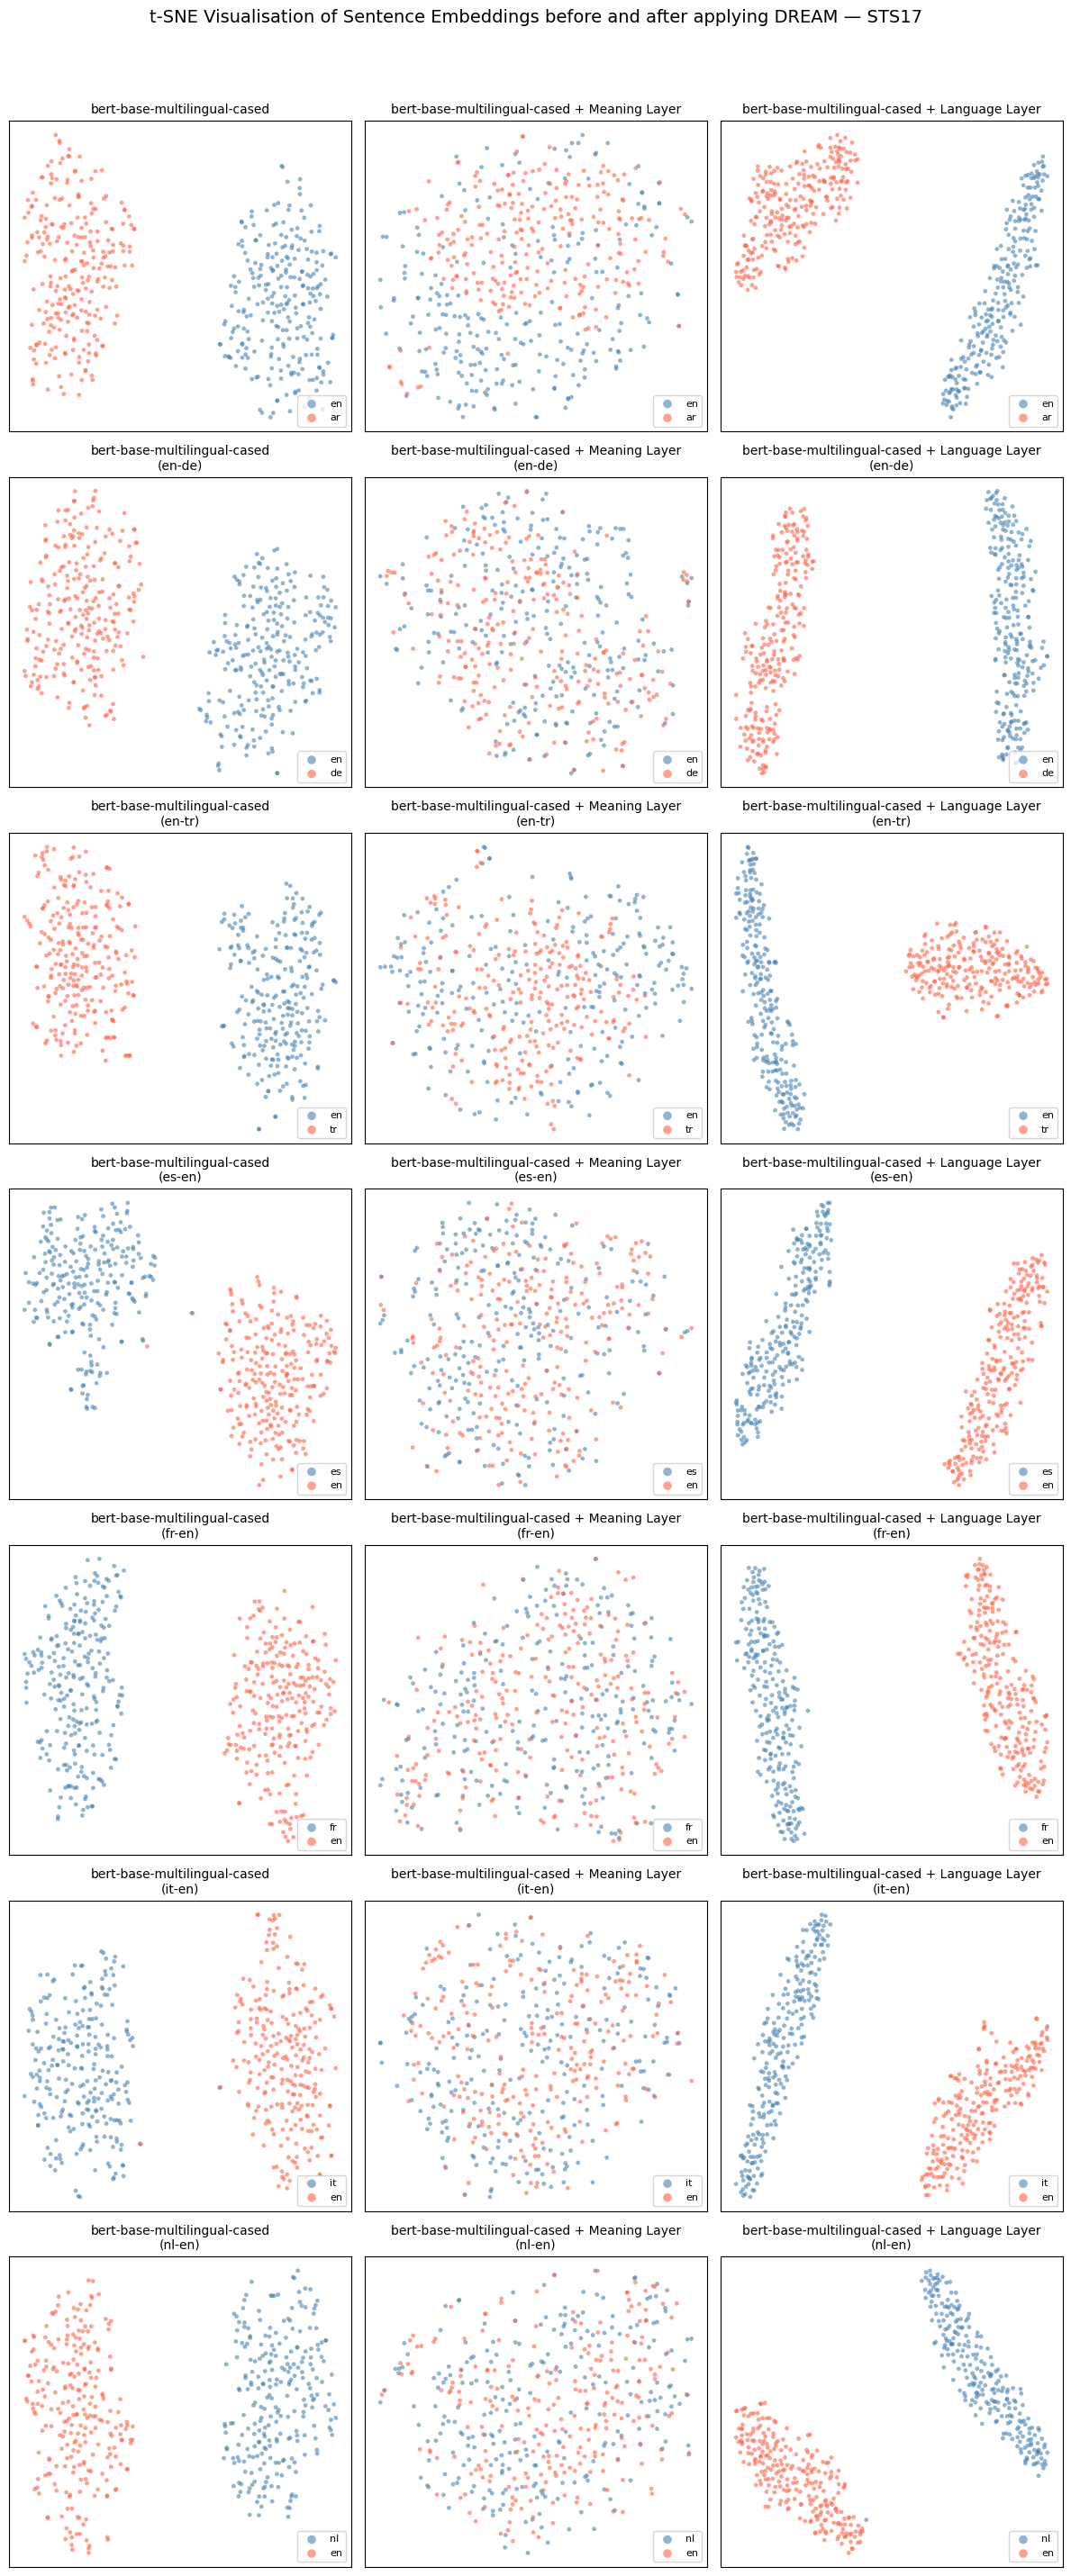

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

TSNE_N = 250  # số câu mỗi ngôn ngữ

def fit_tsne(emb1: np.ndarray, emb2: np.ndarray, n: int = TSNE_N, seed: int = 42) -> tuple:
    idx1 = np.random.RandomState(seed).choice(len(emb1), min(n, len(emb1)), replace=False)
    idx2 = np.random.RandomState(seed).choice(len(emb2), min(n, len(emb2)), replace=False)
    stacked = np.vstack([emb1[idx1], emb2[idx2]])
    coords = TSNE(n_components=2, perplexity=30, random_state=seed, max_iter=1000).fit_transform(stacked)
    return coords, len(idx1)


def plot_tsne_ax(ax, coords: np.ndarray, n1: int, label1: str, label2: str, title: str):
    ax.scatter(coords[:n1, 0], coords[:n1, 1],
               c="steelblue", label=label1, alpha=0.6, s=12, edgecolors="none")
    ax.scatter(coords[n1:, 0], coords[n1:, 1],
               c="tomato",    label=label2, alpha=0.6, s=12, edgecolors="none")
    ax.legend(loc="lower right", fontsize=8, markerscale=2)
    ax.set_title(title, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)


# ── Main plot — mỗi pair là 1 dòng, 3 cột ────────────────────
n_pairs = len(sts17)
fig, axes = plt.subplots(n_pairs, 3, figsize=(12, 4 * n_pairs))

if n_pairs == 1:
    axes = axes[np.newaxis, :]

col_titles = [f"{BACKBONE_DISPLAY_NAME}", f"{BACKBONE_DISPLAY_NAME} + Meaning Layer", f"{BACKBONE_DISPLAY_NAME} + Language Layer"]

for row, data in enumerate(sts17):
    lang1, lang2 = data.lang_pairs.split("-")

    print(f"  Running t-SNE for {data.lang_pairs} …")

    # Col 0 — Backbone raw
    coords, n1 = fit_tsne(data.emb_sent1_backbone, data.emb_sent2_backbone)
    plot_tsne_ax(axes[row, 0], coords, n1, lang1, lang2, title=f"{BACKBONE_DISPLAY_NAME}\n({data.lang_pairs})")

    # Col 1 — DREAM Meaning embedding
    coords, n1 = fit_tsne(data.emb_sent1_dream, data.emb_sent2_dream)
    plot_tsne_ax(axes[row, 1], coords, n1, lang1, lang2, title=f"{BACKBONE_DISPLAY_NAME} + Meaning Layer\n({data.lang_pairs})")

    # Col 2 — DREAM Language embedding
    coords, n1 = fit_tsne(data.lang_sent1_dream, data.lang_sent2_dream)
    plot_tsne_ax(axes[row, 2], coords, n1, lang1, lang2, title=f"{BACKBONE_DISPLAY_NAME} + Language Layer\n({data.lang_pairs})")

# Column headers
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=10)

fig.suptitle("t-SNE Visualisation of Sentence Embeddings before and after applying DREAM — STS17", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f"{BACKBONE_DISPLAY_NAME}_tsne.png", dpi=150, bbox_inches="tight")
plt.show()